# Alternative Algorithms Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Visual configuration
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

## Data Loading and Preparation

In [2]:
# Data Loading
df = pd.read_csv('../data/raw/hepg2.csv')

X = df[['% DMSO', 'TREHALOSE']]
y = df['VIABILIDADE']

# Train/Test split (Single 80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalization for Neural Network and SVR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Standard cross-validation so all models use the same test
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Training and Cross-Validation (All Models)

In [3]:
print("--- CROSS-VALIDATION EVALUATION (5 FOLDS) ---")

# 1. Random Forest (Modelo Base)
rf_model = joblib.load('../random_forest_model.pkl')
y_pred_rf = rf_model.predict(X_test)
cv_rf = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='r2').mean()
print(f"Random Forest -> R² Test: {r2_score(y_test, y_pred_rf):.4f} | R² Cross-Validation: {cv_rf:.4f}")

# 2. Rede Neural Artificial (MLP)
mlp_model = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=2000, random_state=42, early_stopping=True)
mlp_model.fit(X_train_scaled, y_train)
y_pred_mlp = mlp_model.predict(X_test_scaled)
cv_mlp = cross_val_score(mlp_model, X_train_scaled, y_train, cv=cv, scoring='r2').mean()
print(f"Neural Network -> R² Test: {r2_score(y_test, y_pred_mlp):.4f} | R² Cross-Validation: {cv_mlp:.4f}")

# 3. Support Vector Regression (SVR)
svr_model = SVR(kernel='rbf', C=100, gamma=0.1)
svr_model.fit(X_train_scaled, y_train)
y_pred_svr = svr_model.predict(X_test_scaled)
cv_svr = cross_val_score(svr_model, X_train_scaled, y_train, cv=cv, scoring='r2').mean()
print(f"SVR           -> R² Test: {r2_score(y_test, y_pred_svr):.4f} | R² Cross-Validation: {cv_svr:.4f}")

# 4. XGBoost Regressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
cv_xgb = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='r2').mean()
print(f"XGBoost       -> R² Test: {r2_score(y_test, y_pred_xgb):.4f} | R² Cross-Validation: {cv_xgb:.4f}")

--- CROSS-VALIDATION EVALUATION (5 FOLDS) ---


c:\Users\Windows 11\OneDrive\Área de Trabalho\Computação\Fiocruz\hepato_cryo_ai\venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Windows 11\OneDrive\Área de Trabalho\Computação\Fiocruz\hepato_cryo_ai\venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Random Forest -> R² Test: 0.9797 | R² Cross-Validation: 0.9602
Neural Network -> R² Test: 0.6122 | R² Cross-Validation: 0.5849
SVR           -> R² Test: 0.5441 | R² Cross-Validation: 0.2878
XGBoost       -> R² Test: 0.9773 | R² Cross-Validation: 0.9605


# Learning Curves

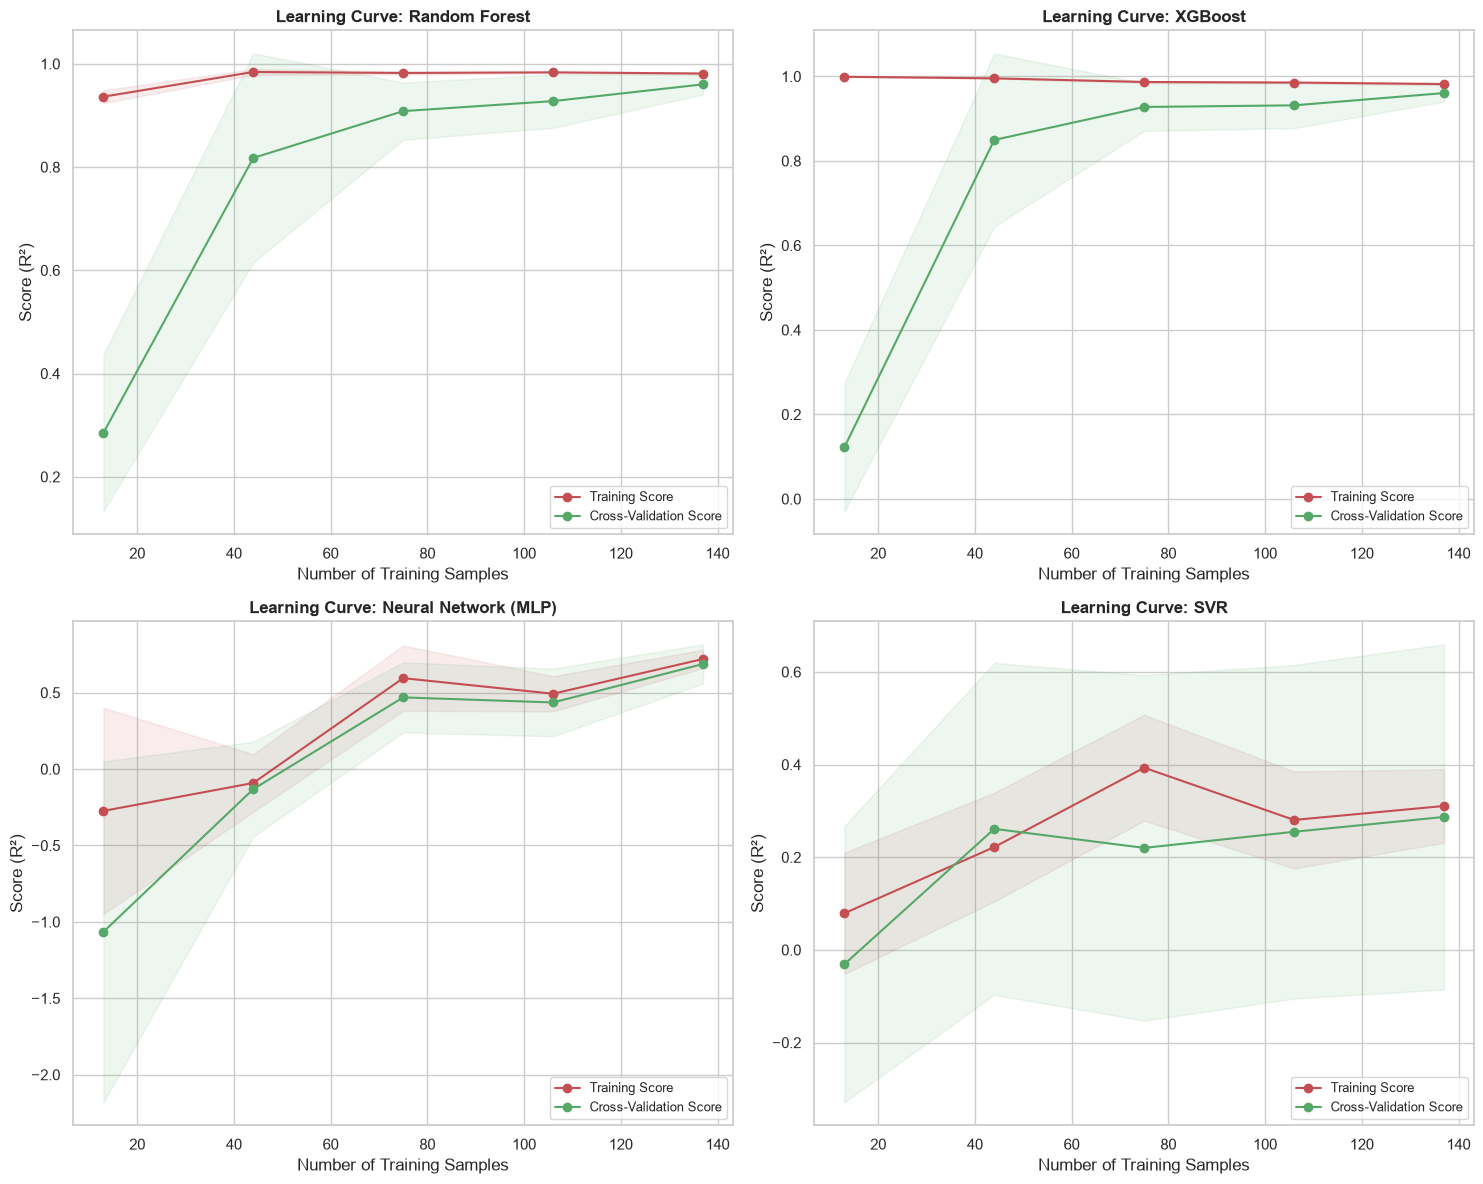

In [4]:
def plotar_curva_aprendizado(estimator, titulo, X_dados, y_dados, eixo):
    """Utility function to compute and plot the learning curve on a subplot."""
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X_dados, y_dados, cv=cv, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='r2'
    )
    
    # Médias e desvios
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    eixo.set_title(titulo, fontweight='bold')
    eixo.set_xlabel("Number of Training Samples")
    eixo.set_ylabel("Score (R²)")
    
    # Sombras de desvio padrão
    eixo.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    eixo.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    
    # Linhas principais
    eixo.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Score")
    eixo.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-Validation Score")
    eixo.legend(loc="lower right", fontsize=9)

# Creating the 4-panel figure (2x2)
fig, ax = plt.subplots(2, 2, figsize=(15, 12))

# Plotando (Atenção para passar os dados normais para árvores e escalonados para SVR/MLP)
plotar_curva_aprendizado(rf_model, "Learning Curve: Random Forest", X_train, y_train, ax[0, 0])
plotar_curva_aprendizado(xgb_model, "Learning Curve: XGBoost", X_train, y_train, ax[0, 1])
plotar_curva_aprendizado(mlp_model, "Learning Curve: Neural Network (MLP)", X_train_scaled, y_train, ax[1, 0])
plotar_curva_aprendizado(svr_model, "Learning Curve: SVR", X_train_scaled, y_train, ax[1, 1])

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=300)
plt.show()

## Visualização Científica

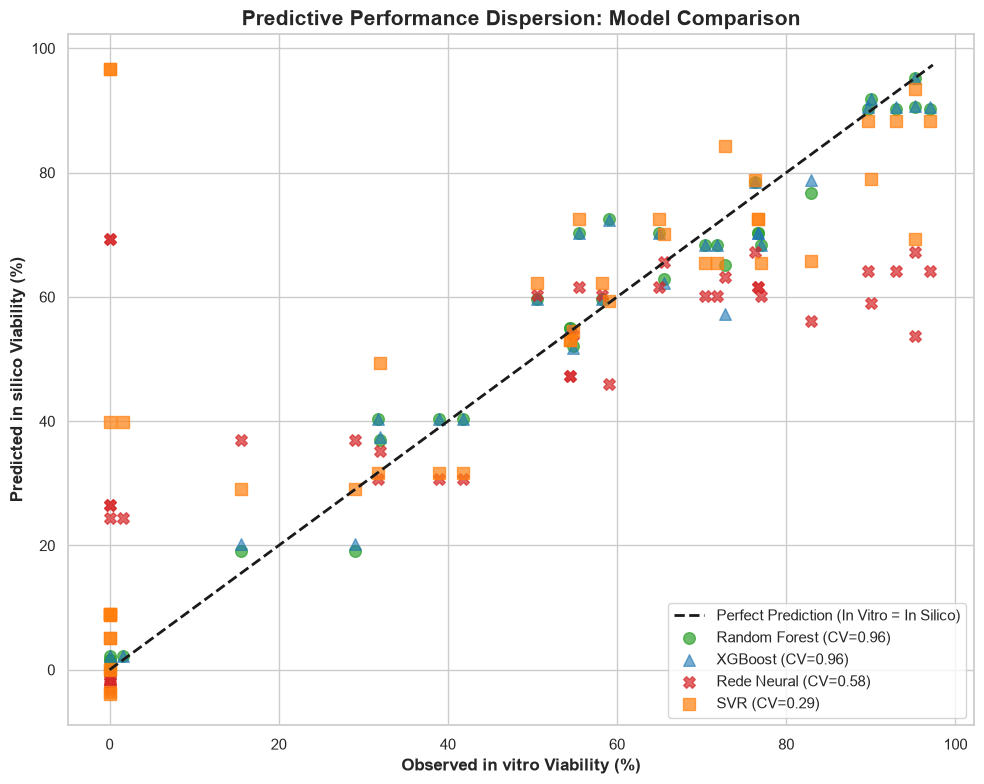

In [5]:
# Setting up the overall comparison plot
plt.figure(figsize=(10, 8))

# Linha Ideal (Predição Perfeita)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Prediction (In Vitro = In Silico)')

# Plotando as famílias de Árvores (Modelos Robustos)
plt.scatter(y_test, y_pred_rf, alpha=0.7, color='#2ca02c', label=f'Random Forest (CV={cv_rf:.2f})', s=70)
plt.scatter(y_test, y_pred_xgb, alpha=0.6, color='#1f77b4', label=f'XGBoost (CV={cv_xgb:.2f})', s=70, marker='^')

# Plotando as famílias de Distância/Pesos (Modelos com Dificuldade nos Limites)
plt.scatter(y_test, y_pred_mlp, alpha=0.7, color='#d62728', label=f'Rede Neural (CV={cv_mlp:.2f})', s=70, marker='X')
plt.scatter(y_test, y_pred_svr, alpha=0.7, color='#ff7f0e', label=f'SVR (CV={cv_svr:.2f})', s=70, marker='s')

plt.xlabel('Observed in vitro Viability (%)', fontweight='bold')
plt.ylabel('Predicted in silico Viability (%)', fontweight='bold')
plt.title('Predictive Performance Dispersion: Model Comparison', fontsize=15, fontweight='bold')
plt.legend()
plt.tight_layout()

plt.savefig('comparison_scatter_4_models.png', dpi=300)
plt.show()